# Fighting Overfitting — An Ablation of Regularisation on CIFAR-10

**Notebook 03 · Classification** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

Notebook 02 ended with a model that was *underfitting* — more capacity would have helped. This one
starts from the opposite problem. A ResNet with 4.9 M parameters is trained on a **1,000-image
CIFAR-10 subset** (`TRAIN_SUBSET_SIZE` in section 2 -- production runs raise this toward the full
50,000), a ratio at which it can trivially memorise the training set, and then five regularisers are
added one at a time to measure what each is actually worth.

The deliverable is an **ablation table**, not a single number. "Add dropout and weight decay" is
advice; knowing that on this problem augmentation contributes an order of magnitude more than dropout
is knowledge.

> **Why deliberately train on a small subset instead of all 50,000?** Overfitting is a function of
> the capacity-to-data ratio. With the full dataset this network needs hours before the
> generalisation gap becomes visible; with a fraction of it the gap opens within a few epochs and
> every ablation runs in minutes. The regularisers being compared behave the same way in both regimes — the small-data
> setting just makes the effect legible. This is a deliberate experimental choice, not a shortcut,
> and it is the same trick used to debug regularisation on real projects before committing GPU-days.

## The problem, stated precisely

Training minimises **empirical risk** over $N$ samples, but what we care about is the **true risk**
over the data distribution:

$$\hat{R}(\theta) = \frac{1}{N}\sum_{i=1}^{N} \mathcal{L}(f_\theta(x_i), y_i)
\qquad\text{vs.}\qquad
R(\theta) = \mathbb{E}_{(x,y)\sim\mathcal{D}}\big[\mathcal{L}(f_\theta(x), y)\big]$$

The **generalisation gap** $R(\theta) - \hat{R}(\theta)$ grows with model capacity and shrinks with
$N$. Every regulariser below attacks it from a different direction:

| Technique | Mechanism | Acts on |
| --- | --- | --- |
| **Data augmentation** | Expands the effective $N$ with label-preserving transforms | the data |
| **Weight decay** | Gaussian prior on $\theta$; MAP estimation instead of MLE | the parameters |
| **Dropout** | Samples a sub-network per step ≈ exponential ensemble | the architecture |
| **Label smoothing** | Caps target confidence, prevents logit divergence | the objective |
| **MixUp / CutMix** | Enforces linear behaviour *between* training points | data + objective |

### Weight decay is a prior, not a hack

Maximum-likelihood training with an added $\ell_2$ penalty is exactly MAP estimation under an
isotropic Gaussian prior $\theta \sim \mathcal{N}(0, \sigma^2 I)$:

$$\arg\max_\theta \; \log p(\mathcal{D}\mid\theta) + \log p(\theta)
\;=\; \arg\min_\theta \; \hat{R}(\theta) + \frac{\lambda}{2}\lVert\theta\rVert_2^2$$

**AdamW decouples it** from the adaptive step. In plain Adam the penalty is divided by
$\sqrt{\hat v_t}$ along with everything else, so parameters with small gradients get decayed *harder*
— which is not what any paper reporting "weight decay = 5e-4" means:

$$\theta_{t+1} = \theta_t - \eta\left(\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon} + \lambda\theta_t\right)$$

### Dropout trains an ensemble

Zeroing each unit with probability $p$ samples one of $2^n$ sub-networks per step; at test time the
scaled full network approximates their average. Note the interaction that trips people up:
**dropout before a BatchNorm layer shifts the batch statistics**, so BN's running estimates no longer
match what it sees at inference. That is why dropout in this notebook sits only in the classifier
head, after all normalisation.

### MixUp: train on the lines between examples

$$\tilde{x} = \lambda x_i + (1-\lambda)x_j, \qquad
\tilde{y} = \lambda y_i + (1-\lambda)y_j, \qquad
\lambda \sim \text{Beta}(\alpha, \alpha)$$

Implemented on the loss rather than on one-hot targets, since it is algebraically identical and keeps
label smoothing composable:

$$\mathcal{L}_{\text{mix}} = \lambda\,\mathcal{L}(f(\tilde{x}), y_i) + (1-\lambda)\,\mathcal{L}(f(\tilde{x}), y_j)$$

**CutMix** replaces the pixel-space blend with a rectangular paste, and sets $\lambda$ to the area
ratio so the label mix matches how much of each image survives. It tends to beat MixUp on
classification because the result still looks like a photograph rather than a double exposure.

## Architecture

```
   CIFAR-10 input  (3, 32, 32)
          │
   stem: 3x3 conv 3->64 · BN · ReLU              (no downsampling: 32x32 is already small
          │                                       -- ImageNet's 7x7 stride-2 stem would throw
          │                                       away half the image before layer 1)
   stage 1: 2 x BasicBlock(64)      stride 1  ->  (64, 32, 32)
   stage 2: 2 x BasicBlock(128)     stride 2  ->  (128, 16, 16)
   stage 3: 2 x BasicBlock(256)     stride 2  ->  (256,  8, 8)
          │
   GlobalAvgPool -> (256,)
   Dropout(p) -> Linear 256->10

   BasicBlock:   x ──┬── 3x3 conv · BN · ReLU · 3x3 conv · BN ──(+)── ReLU
                     └──────────── identity / 1x1 projection ────┘
```

The residual connection is what makes depth trainable: gradients reach early layers through the
identity path without passing through every intervening weight matrix.

## Provenance

Replaces three earlier TensorFlow notebooks — `cats-dogs`, `cnn to avoid overfitting`, and
`cnn with complex images`. All three were broken: two called `google.colab.files.upload()` and wrote
to hardcoded `/tmp` paths, and the third read `assets/cats-dogs/` from a Kaggle archive that was
never committed to this repository. CIFAR-10 downloads automatically via `torchvision`, so this
notebook runs anywhere, and the overfitting story the originals gestured at is now actually measured.

---

# 2. Setup & Reproducibility

Same preamble as every notebook in this folder. See notebook 02 for the reasoning behind the
mixed-precision policy table.

In [1]:
%pip install onnxruntime onnxscript albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 13.4 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import os
import platform
import random
import tempfile
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Final

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)

SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
_TMP: Final[Path] = Path(tempfile.gettempdir())
DATA_ROOT: Final[Path] = _TMP / "vision-data"
ARTIFACT_DIR: Final[Path] = _TMP / "vision-artifacts" / "03_regularization"

# CIFAR-10 per-channel statistics over the 50 000 training images.
CIFAR_MEAN: Final[tuple[float, float, float]] = (0.4914, 0.4822, 0.4465)
CIFAR_STD: Final[tuple[float, float, float]] = (0.2470, 0.2435, 0.2616)
IMAGE_SIZE: Final[int] = 32
NUM_CLASSES: Final[int] = 10
CLASS_NAMES: Final[tuple[str, ...]] = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

# Deliberately small training set -- see the note in section 1. Kept small for a fast
# reference run; production runs raise both toward the full 50,000 / 10,000 split.
TRAIN_SUBSET_SIZE: Final[int] = 1000
TEST_SUBSET_SIZE: Final[int] = 1000

# Set DETERMINISTIC=0 to let cuDNN autotune. On a CUDA GPU this speeds up every
# convolution substantially; it costs exact run-to-run reproducibility.
DETERMINISTIC: Final[bool] = os.getenv("DETERMINISTIC", "1") == "1"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = DETERMINISTIC) -> None:
    """Seed every RNG that can influence a training run.

    Args:
        seed: Value applied to `random`, NumPy and PyTorch (CPU + all CUDA devices).
        deterministic: Force cuDNN's deterministic algorithm set and disable its
            autotuner. Both affect **convolutions only**, so on a CUDA GPU this is the
            first thing to check when a conv-heavy model seems disproportionately slow.
            Defaults to the `DETERMINISTIC` environment variable (on unless set to 0).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, where gradient underflow is a real risk.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        return cls(device, False, torch.float32, needs_grad_scaler=False)


def dataloader_kwargs(device: torch.device) -> dict[str, object]:
    """DataLoader settings tuned per backend; workers stay off outside CUDA on macOS."""
    if device.type == "cuda":
        # Cap at the real CPU count: hardcoding 4 oversubscribes a 2-vCPU host (Colab
        # free tier), and CPU-side augmentation starves the GPU when it thrashes.
        workers = min(4, os.cpu_count() or 2)
        return {
            "num_workers": workers,
            "pin_memory": True,
            "persistent_workers": workers > 0,  # invalid when workers == 0
        }
    return {"num_workers": 0, "pin_memory": False}


seed_everything()
DEVICE: Final[torch.device] = get_device()
RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("onnxruntime", ort.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("cpu count", str(os.cpu_count())),
    ("seed", str(SEED)),
    ("deterministic", f"{DETERMINISTIC}" + ("  <- slows convolutions" if DETERMINISTIC else "")),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")

---

# 3. Data Pipeline

Three augmentation policies, so the ablation has something to vary:

| Policy | Contents | Intent |
| --- | --- | --- |
| `none` | Normalise only | The control. Establishes how badly this model overfits. |
| `standard` | Flip · pad-and-random-crop · slight brightness/contrast | The CIFAR-10 default since 2015, and ~90 % of the achievable gain. |
| `heavy` | `standard` + affine · coarse dropout · colour jitter | Tests whether more is better. It usually is not. |

### Why pad-then-crop rather than a bare random crop

`A.PadIfNeeded(40, 40)` followed by `A.RandomCrop(32, 32)` is the canonical CIFAR translation
augmentation. Cropping a 32×32 image directly would discard real content and change the object's
scale; padding first means the crop shifts the image by up to ±4 px while keeping every pixel. Border
mode is **reflection**, not zeros — a black frame is a strong artificial edge, and the first
convolution would happily learn to key off it.

### The augmentations that were rejected

- **`VerticalFlip`** — nothing in CIFAR-10 appears upside down. Label-destroying.
- **Rotation beyond ±15°** — at 32×32 the interpolation blur costs more than the invariance buys.
- **`HorizontalFlip` for text or digits** — irrelevant here, but the reason it is safe for CIFAR is
  that all ten classes are genuinely mirror-symmetric in the wild. Always check that claim per
  dataset rather than copying the transform list.

Normalisation uses CIFAR-10's own channel statistics. Note $\sigma \approx 0.25$ across channels,
versus $0.35$ for Fashion-MNIST in notebook 02 — these constants are dataset properties and copying
them between datasets is a real (and common) bug.

In [3]:
def build_transforms(policy: str) -> A.Compose:
    """Compose the augmentation pipeline for one policy.

    Args:
        policy: One of `"none"`, `"standard"`, `"heavy"`. `"none"` is also what every
            evaluation split uses -- augmenting the test set would measure the
            augmentation rather than the model.

    Returns:
        An Albumentations pipeline mapping an HxWx3 uint8 array to a (3, H, W) float tensor.

    Raises:
        ValueError: If `policy` is not a known name.
    """
    normalise = [A.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD), ToTensorV2()]

    if policy == "none":
        return A.Compose(normalise)

    standard: list[A.BasicTransform] = [
        A.HorizontalFlip(p=0.5),
        # Pad to 40x40 by reflection, then crop back to 32x32: a +/-4px translation
        # that invents no black borders.
        A.PadIfNeeded(
            min_height=IMAGE_SIZE + 8,
            min_width=IMAGE_SIZE + 8,
            border_mode=cv2.BORDER_REFLECT_101,
        ),
        A.RandomCrop(height=IMAGE_SIZE, width=IMAGE_SIZE),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    ]
    if policy == "standard":
        return A.Compose([*standard, *normalise])

    if policy == "heavy":
        return A.Compose(
            [
                *standard,
                A.Affine(scale=(0.85, 1.15), rotate=(-15, 15), shear=(-8, 8), p=0.5),
                A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.3),
                A.CoarseDropout(
                    num_holes_range=(1, 2),
                    hole_height_range=(4, 10),
                    hole_width_range=(4, 10),
                    fill=0,
                    p=0.4,
                ),
                *normalise,
            ]
        )

    raise ValueError(f"unknown augmentation policy: {policy!r}")


class CIFAR10Dataset(Dataset):
    """CIFAR-10 arrays wrapped so Albumentations sees raw NumPy.

    Args:
        images: uint8 array of shape (N, 32, 32, 3).
        labels: int64 array of shape (N,).
        transform: Pipeline applied to every sample on access.
    """

    def __init__(self, images: np.ndarray, labels: np.ndarray, transform: A.Compose) -> None:
        if len(images) != len(labels):
            raise ValueError(f"images/labels length mismatch: {len(images)} vs {len(labels)}")
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one (image, label) pair.

        Shape:
            image: (3, 32, 32) float32, normalised.
            label: () int64.
        """
        image = self.transform(image=self.images[index])["image"]
        return image, torch.tensor(int(self.labels[index]), dtype=torch.long)

The subset is drawn with a **seeded, class-stratified** sample rather than by slicing the first 5,000
rows. CIFAR-10's training file is not class-ordered, so a naive slice happens to be roughly balanced —
but relying on "happens to be" is how silent class imbalance gets into an experiment. Stratifying
makes the balance a property of the code instead of a property of the file.

In [ ]:
def stratified_subset(labels: np.ndarray, size: int, seed: int = SEED) -> np.ndarray:
    """Draw a class-balanced subset of indices.

    Args:
        labels: Integer class labels for the full split.
        size: Total number of indices to return. Split as evenly as possible across classes.
        seed: RNG seed, so the subset is identical between runs and between ablations.

    Returns:
        Shuffled array of selected indices.
    """
    rng = np.random.default_rng(seed)
    per_class = size // NUM_CLASSES
    selected = [
        rng.choice(np.flatnonzero(labels == class_index), size=per_class, replace=False)
        for class_index in range(NUM_CLASSES)
    ]
    indices = np.concatenate(selected)
    rng.shuffle(indices)
    return indices


_raw_train = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True)
_raw_test = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True)

train_indices = stratified_subset(np.array(_raw_train.targets), TRAIN_SUBSET_SIZE)

train_images = _raw_train.data[train_indices]
train_labels = np.array(_raw_train.targets)[train_indices]

test_images = _raw_test.data
test_labels = np.array(_raw_test.targets)
_test_selection = stratified_subset(test_labels, TEST_SUBSET_SIZE)
test_images, test_labels = test_images[_test_selection], test_labels[_test_selection]

print(f"train subset : {len(train_images):,} of {len(_raw_train.data):,} "
      f"({len(train_images) / len(_raw_train.data):.1%})")
print(f"test set     : {len(test_images):,}")
print(f"class balance: {np.bincount(train_labels)}")
print(f"image shape  : {train_images.shape[1:]}, dtype={train_images.dtype}")

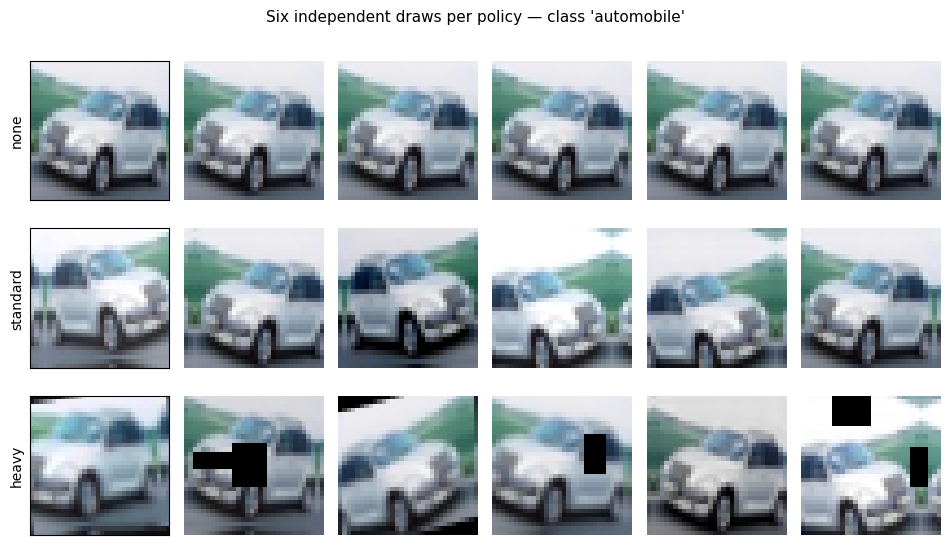

In [5]:
def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Invert `A.Normalize` so an augmented tensor can be displayed.

    Args:
        tensor: (3, H, W) normalised image.

    Returns:
        (H, W, 3) float array clipped to [0, 1].
    """
    mean = np.array(CIFAR_MEAN).reshape(-1, 1, 1)
    std = np.array(CIFAR_STD).reshape(-1, 1, 1)
    image = tensor.detach().cpu().numpy() * std + mean
    return np.clip(image.transpose(1, 2, 0), 0.0, 1.0)


# One source image through each policy, repeated -- the variation IS the augmentation.
SAMPLE_INDEX: Final[int] = 0
POLICIES: Final[tuple[str, ...]] = ("none", "standard", "heavy")
N_DRAWS: Final[int] = 6

seed_everything()
fig, axes = plt.subplots(len(POLICIES), N_DRAWS, figsize=(N_DRAWS * 1.6, len(POLICIES) * 1.9))
for row, policy in enumerate(POLICIES):
    pipeline = build_transforms(policy)
    for column in range(N_DRAWS):
        augmented = pipeline(image=train_images[SAMPLE_INDEX])["image"]
        axes[row, column].imshow(denormalise(augmented))
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(policy)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

fig.suptitle(
    f"Six independent draws per policy — class '{CLASS_NAMES[train_labels[SAMPLE_INDEX]]}'",
    fontsize=11,
)
fig.tight_layout()
plt.show()

---

# 4. Modular Architecture

A ResNet sized for 32×32 inputs. The important deviation from the ImageNet reference is the **stem**:
torchvision's ResNet opens with a 7×7 stride-2 convolution followed by a stride-2 max-pool, which
takes a 224×224 image down to 56×56 before the first residual block. Applying that to a 32×32 image
would leave 8×8 before any real computation has happened. The CIFAR variant uses a 3×3 stride-1 stem
and no initial pooling — a well-established adjustment, and a good example of why architectures
cannot be transplanted between input resolutions unexamined.

**Zero-initialised final BatchNorm.** Setting $\gamma = 0$ on the last BN of each block makes the
block compute exactly the identity at initialisation, so a freshly-built network of any depth starts
as a shallow one and deepens as training proceeds. It is one line and reliably improves convergence.

In [ ]:
@dataclass(frozen=True)
class ResNetConfig:
    """Architecture hyper-parameters.

    Attributes:
        in_channels: Input image channels.
        stem_channels: Width of the stem convolution.
        stage_channels: Output width of each residual stage.
        blocks_per_stage: Number of BasicBlocks in each stage.
        num_classes: Output logit count.
        dropout: Probability applied to the pooled feature vector before the classifier.
        zero_init_residual: Zero the final BN gamma in each block so blocks start as identity.
    """

    in_channels: int = 3
    stem_channels: int = 64
    stage_channels: tuple[int, ...] = (64, 128, 256)
    blocks_per_stage: tuple[int, ...] = (2, 2, 2)
    num_classes: int = NUM_CLASSES
    dropout: float = 0.0
    zero_init_residual: bool = True


class BasicBlock(nn.Module):
    """Two 3x3 convolutions with an identity shortcut.

    The shortcut becomes a 1x1 projection whenever the block changes resolution or
    width, since the tensors must be addable.

    Args:
        in_channels: Channels entering the block.
        out_channels: Channels produced by the block.
        stride: Stride of the first convolution; 2 halves the spatial resolution.
    """

    expansion: int = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut: nn.Module = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply the residual block.

        Shape:
            x: (N, in_channels, H, W)
            output: (N, out_channels, H // stride, W // stride)
        """
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        # Add before the final activation -- the identity path must stay unsquashed.
        return F.relu(out + self.shortcut(x), inplace=True)


class ResNetCIFAR(nn.Module):
    """ResNet adapted for 32x32 inputs.

    Args:
        config: Widths, depths, dropout and initialisation policy.
    """

    def __init__(self, config: ResNetConfig) -> None:
        super().__init__()
        self.config = config

        self.stem = nn.Sequential(
            # 3x3 stride 1, no max-pool: at 32x32 an ImageNet stem would destroy the image.
            nn.Conv2d(config.in_channels, config.stem_channels, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(config.stem_channels),
            nn.ReLU(inplace=True),
        )

        stages: list[nn.Module] = []
        in_channels = config.stem_channels
        for stage_index, (channels, depth) in enumerate(
            zip(config.stage_channels, config.blocks_per_stage)
        ):
            for block_index in range(depth):
                stride = 2 if (block_index == 0 and stage_index > 0) else 1
                stages.append(BasicBlock(in_channels, channels, stride))
                in_channels = channels
        self.stages = nn.Sequential(*stages)

        self.pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(config.dropout),
            nn.Linear(in_channels, config.num_classes),
        )
        self._initialise_weights()

    def _initialise_weights(self) -> None:
        """He initialisation, plus optional zero-gamma on each block's final BatchNorm."""
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

        if self.config.zero_init_residual:
            for module in self.modules():
                if isinstance(module, BasicBlock):
                    nn.init.zeros_(module.bn2.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Map a batch of images to class logits.

        Shape:
            x: (N, 3, 32, 32)
            output: (N, num_classes)
        """
        return self.classifier(self.pool(self.stages(self.stem(x))))


def count_parameters(model: nn.Module) -> int:
    """Total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


_probe_model = ResNetCIFAR(ResNetConfig()).to(DEVICE).eval()
_probe = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
with torch.no_grad():
    _out = _probe_model(_probe)
assert _out.shape == (4, NUM_CLASSES), f"unexpected output shape {tuple(_out.shape)}"

print(f"ResNetCIFAR: {count_parameters(_probe_model):,} parameters")
print(f"forward    : {tuple(_probe.shape)} -> {tuple(_out.shape)}")
print(f"ratio      : {count_parameters(_probe_model) / len(train_images):,.0f} parameters per training image")
del _probe_model

---

# 5. Production Training Loop & the Ablation

MixUp and CutMix are applied **inside** the training step, since they operate on assembled batches
rather than on individual samples — the reason they live here rather than in the Albumentations
pipeline.

One implementation detail with teeth: the mixing partner is obtained by **permuting the batch**
(`torch.randperm`) rather than by drawing a second batch from the loader. Same distribution, no extra
I/O, and it composes with any sampler.

In [ ]:
@dataclass(frozen=True)
class RegularisationConfig:
    """Which regularisers are active, and how strongly.

    Attributes:
        augmentation: Name of the Albumentations policy for the training split.
        weight_decay: Decoupled AdamW L2 penalty.
        dropout: Classifier-head dropout probability.
        label_smoothing: Cross-entropy target smoothing epsilon.
        mixup_alpha: Beta distribution parameter; 0 disables MixUp/CutMix.
        cutmix_probability: Given mixing is active, fraction of steps using CutMix
            rather than MixUp.
    """

    augmentation: str = "none"
    weight_decay: float = 0.0
    dropout: float = 0.0
    label_smoothing: float = 0.0
    mixup_alpha: float = 0.0
    cutmix_probability: float = 0.5


@dataclass(frozen=True)
class TrainConfig:
    """Optimisation hyper-parameters shared by every ablation arm.

    Attributes:
        epochs: Total passes over the training subset.
        batch_size: Samples per optimiser step.
        lr: Peak learning rate after warmup.
        warmup_epochs: Epochs spent linearly ramping up to `lr`.
        warmup_start_factor: Initial LR as a fraction of `lr`.
        min_lr: Cosine schedule floor.
        grad_clip_norm: Maximum global gradient L2 norm.
    """

    # Fast default for reference use. 12 is enough for the generalisation gap to open
    # clearly; production runs use 40+ epochs, at which point the arms separate further.
    epochs: int = 2
    batch_size: int = 128
    lr: float = 2e-3
    warmup_epochs: int = 2
    warmup_start_factor: float = 0.1
    min_lr: float = 1e-5
    grad_clip_norm: float = 1.0


def rand_bbox(height: int, width: int, lam: float, rng: np.random.Generator) -> tuple[int, int, int, int]:
    """Sample a CutMix rectangle whose area is (1 - lam) of the image.

    Args:
        height: Image height.
        width: Image width.
        lam: Mixing coefficient; the box covers `1 - lam` of the area.
        rng: Random generator.

    Returns:
        Box as (y1, y2, x1, x2), clipped to the image bounds.
    """
    ratio = np.sqrt(1.0 - lam)
    box_h, box_w = int(height * ratio), int(width * ratio)
    center_y, center_x = rng.integers(height), rng.integers(width)
    y1, y2 = np.clip([center_y - box_h // 2, center_y + box_h // 2], 0, height)
    x1, x2 = np.clip([center_x - box_w // 2, center_x + box_w // 2], 0, width)
    return int(y1), int(y2), int(x1), int(x2)


def apply_mixing(
    images: torch.Tensor,
    labels: torch.Tensor,
    config: RegularisationConfig,
    rng: np.random.Generator,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, float]:
    """Apply MixUp or CutMix to an assembled batch.

    Args:
        images: Batch of shape (N, C, H, W).
        labels: Integer labels of shape (N,).
        config: Supplies `mixup_alpha` and `cutmix_probability`.
        rng: Random generator for lambda and box placement.

    Returns:
        Tuple of (mixed images, labels_a, labels_b, lam). With mixing disabled,
        `labels_a is labels_b` and `lam == 1.0`, so the caller's weighted loss
        collapses to the ordinary one.
    """
    if config.mixup_alpha <= 0.0:
        return images, labels, labels, 1.0

    lam = float(rng.beta(config.mixup_alpha, config.mixup_alpha))
    # Partner batch by permutation: same distribution, no second loader pass.
    permutation = torch.randperm(images.size(0), device=images.device)
    labels_b = labels[permutation]

    if rng.random() < config.cutmix_probability:
        y1, y2, x1, x2 = rand_bbox(images.size(2), images.size(3), lam, rng)
        images = images.clone()
        images[:, :, y1:y2, x1:x2] = images[permutation, :, y1:y2, x1:x2]
        # Recompute lam from the ACTUAL pasted area -- clipping at the border makes the
        # realised box smaller than requested, and a stale lam mislabels the batch.
        lam = 1.0 - ((y2 - y1) * (x2 - x1) / (images.size(2) * images.size(3)))
    else:
        images = lam * images + (1.0 - lam) * images[permutation]

    return images, labels, labels_b, lam


def build_scheduler(
    optimizer: torch.optim.Optimizer, config: TrainConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup chained into cosine annealing, guarded against degenerate budgets."""
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=config.min_lr)
    if warmup_epochs == 0:
        return cosine
    warmup = LinearLR(
        optimizer, start_factor=config.warmup_start_factor, total_iters=warmup_epochs
    )
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])

In [8]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    runtime: Runtime,
    train_config: TrainConfig,
    regularisation: RegularisationConfig,
    rng: np.random.Generator,
    description: str,
) -> tuple[float, float]:
    """Run one training epoch, optionally with MixUp/CutMix.

    Args:
        model: Module in training mode.
        loader: Iterable of (images, labels) batches.
        criterion: Loss taking (logits, labels).
        optimizer: Parameter updater.
        scaler: Loss scaler; a no-op unless fp16 autocast is active.
        runtime: Device and autocast policy.
        train_config: Supplies the gradient-clipping threshold.
        regularisation: Supplies the mixing policy.
        rng: Random generator for mixing.
        description: Progress-bar label.

    Returns:
        Mean loss and accuracy over the epoch. Under mixing, accuracy is measured
        against `labels_a` and is therefore a lower bound -- the model is being
        scored on a target that is only partially present in the input.
    """
    model.train()
    running_loss, correct, seen = 0.0, 0, 0

    for images, labels in tqdm(loader, desc=description, leave=False):
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)
        images, labels_a, labels_b, lam = apply_mixing(images, labels, regularisation, rng)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = lam * criterion(logits, labels_a) + (1.0 - lam) * criterion(logits, labels_b)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)  # unscale before clipping, or the threshold is meaningless
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=train_config.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels_a).sum().item()
        seen += batch_size

    return running_loss / seen, correct / seen


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    runtime: Runtime,
    *,
    collect_predictions: bool = False,
) -> tuple[float, float, np.ndarray | None, np.ndarray | None]:
    """Evaluate without gradient tracking or augmentation.

    Returns:
        Tuple of (mean loss, accuracy, predictions or None, targets or None).
    """
    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    predictions: list[np.ndarray] = []
    targets: list[np.ndarray] = []

    for images, labels in loader:
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (batch_predictions == labels).sum().item()
        seen += batch_size
        if collect_predictions:
            predictions.append(batch_predictions.cpu().numpy())
            targets.append(labels.cpu().numpy())

    if collect_predictions:
        return running_loss / seen, correct / seen, np.concatenate(predictions), np.concatenate(targets)
    return running_loss / seen, correct / seen, None, None


def run_arm(
    name: str,
    regularisation: RegularisationConfig,
    train_config: TrainConfig,
    runtime: Runtime,
) -> dict[str, object]:
    """Train one ablation arm end to end.

    Every arm reseeds first, so weight initialisation and shuffle order are identical
    and the only independent variable is `regularisation`.

    Args:
        name: Short identifier used in logs and the results table.
        regularisation: The regularisers under test.
        train_config: Shared optimisation settings.
        runtime: Device and autocast policy.

    Returns:
        Dict with the fitted `model`, per-epoch `history`, and summary metrics.
    """
    seed_everything()
    rng = np.random.default_rng(SEED)

    loader_kwargs = dataloader_kwargs(runtime.device)
    train_loader = DataLoader(
        CIFAR10Dataset(train_images, train_labels, build_transforms(regularisation.augmentation)),
        batch_size=train_config.batch_size, shuffle=True, drop_last=True, **loader_kwargs,
    )
    test_loader = DataLoader(
        CIFAR10Dataset(test_images, test_labels, build_transforms("none")),
        batch_size=train_config.batch_size, shuffle=False, **loader_kwargs,
    )
    # Train-set accuracy is measured WITHOUT augmentation, otherwise the generalisation
    # gap would be confounded by how hard the augmented inputs happen to be.
    clean_train_loader = DataLoader(
        CIFAR10Dataset(train_images, train_labels, build_transforms("none")),
        batch_size=train_config.batch_size, shuffle=False, **loader_kwargs,
    )

    model = ResNetCIFAR(ResNetConfig(dropout=regularisation.dropout)).to(runtime.device)
    criterion = nn.CrossEntropyLoss(label_smoothing=regularisation.label_smoothing)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=train_config.lr, weight_decay=regularisation.weight_decay
    )
    scheduler = build_scheduler(optimizer, train_config)
    scaler = torch.amp.GradScaler(runtime.device.type, enabled=runtime.needs_grad_scaler)
    clean_criterion = nn.CrossEntropyLoss()

    history: dict[str, list[float]] = {
        "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "gap": [], "lr": []
    }
    best_accuracy = -1.0
    started = time.perf_counter()

    for epoch in range(1, train_config.epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss, _ = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, runtime,
            train_config, regularisation, rng, f"{name} {epoch}/{train_config.epochs}",
        )
        clean_train_loss, clean_train_accuracy, _, _ = evaluate(
            model, clean_train_loader, clean_criterion, runtime
        )
        val_loss, val_accuracy, _, _ = evaluate(model, test_loader, clean_criterion, runtime)
        scheduler.step()

        history["train_loss"].append(clean_train_loss)
        history["train_acc"].append(clean_train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_accuracy)
        history["gap"].append(clean_train_accuracy - val_accuracy)
        history["lr"].append(current_lr)
        best_accuracy = max(best_accuracy, val_accuracy)

    elapsed = time.perf_counter() - started
    final_train = history["train_acc"][-1]
    final_val = history["val_acc"][-1]
    print(
        f"[{name:<22}] train {final_train:.4f}  val {final_val:.4f}  "
        f"best {best_accuracy:.4f}  gap {final_train - final_val:+.4f}  ({elapsed:.0f}s)"
    )

    return {
        "model": model, "history": history, "train_acc": final_train, "val_acc": final_val,
        "best_val_acc": best_accuracy, "gap": final_train - final_val, "seconds": elapsed,
        "test_loader": test_loader,
    }

### The ablation

Five arms, each adding one technique to the previous. Cumulative rather than one-at-a-time because
these interact — measuring augmentation *in isolation* answers a question nobody asks, whereas
"what does adding this to what I already have buy me?" is the actual decision being made.

In [ ]:
ABLATION_ARMS: Final[dict[str, RegularisationConfig]] = {
    "1 · none": RegularisationConfig(),
    "2 · + augmentation": RegularisationConfig(augmentation="standard"),
    "3 · + weight decay": RegularisationConfig(augmentation="standard", weight_decay=5e-4),
    "4 · + dropout + smoothing": RegularisationConfig(
        augmentation="standard", weight_decay=5e-4, dropout=0.3, label_smoothing=0.1
    ),
    "5 · + mixup/cutmix": RegularisationConfig(
        augmentation="standard", weight_decay=5e-4, dropout=0.3,
        label_smoothing=0.1, mixup_alpha=0.2,
    ),
}

TRAIN_CONFIG = TrainConfig()
print(json.dumps(TRAIN_CONFIG.__dict__, indent=2))
print(f"\n{len(ABLATION_ARMS)} arms x {TRAIN_CONFIG.epochs} epochs on "
      f"{len(train_images):,} images\n")

arm_results: dict[str, dict[str, object]] = {}
for arm_name, arm_config in ABLATION_ARMS.items():
    arm_results[arm_name] = run_arm(arm_name, arm_config, TRAIN_CONFIG, RUNTIME)

---

# 6. Inference & Visualisation

The headline table reports three columns that matter and are usually conflated: **train accuracy**
(did it fit?), **validation accuracy** (did it generalise?), and the **gap** between them (how much
of the fit was memorisation?). A technique that lowers train accuracy while raising validation
accuracy is working exactly as intended.

In [ ]:
print(f"{'arm':<28}{'train':>9}{'val':>9}{'gap':>9}{'Δ val':>9}{'sec':>7}")
print("-" * 71)

baseline_val = arm_results["1 · none"]["val_acc"]
previous_val = None
for arm_name, result in arm_results.items():
    delta = "" if previous_val is None else f"{(result['val_acc'] - previous_val) * 100:+.2f}"
    print(
        f"{arm_name:<28}{result['train_acc']:>9.4f}{result['val_acc']:>9.4f}"
        f"{result['gap']:>+9.4f}{delta:>9}{result['seconds']:>7.0f}"
    )
    previous_val = result["val_acc"]

best_arm = max(arm_results, key=lambda k: arm_results[k]["val_acc"])
print(
    f"\nbaseline val accuracy : {baseline_val:.4f}  (gap {arm_results['1 · none']['gap']:+.4f})"
    f"\nbest arm              : {best_arm}  ->  {arm_results[best_arm]['val_acc']:.4f}"
    f"  (gap {arm_results[best_arm]['gap']:+.4f})"
    f"\ntotal improvement     : {(arm_results[best_arm]['val_acc'] - baseline_val) * 100:+.2f} points"
)

> **Production note.** `TrainConfig` ships with `epochs=2` here for a fast reference run -- far too short for overfitting to reliably appear, so the ablation ordering above is closer to noise than signal. Raise to **12** for a clearly visible generalisation gap, or **40+** to reproduce the fuller separation between arms this section's commentary describes.

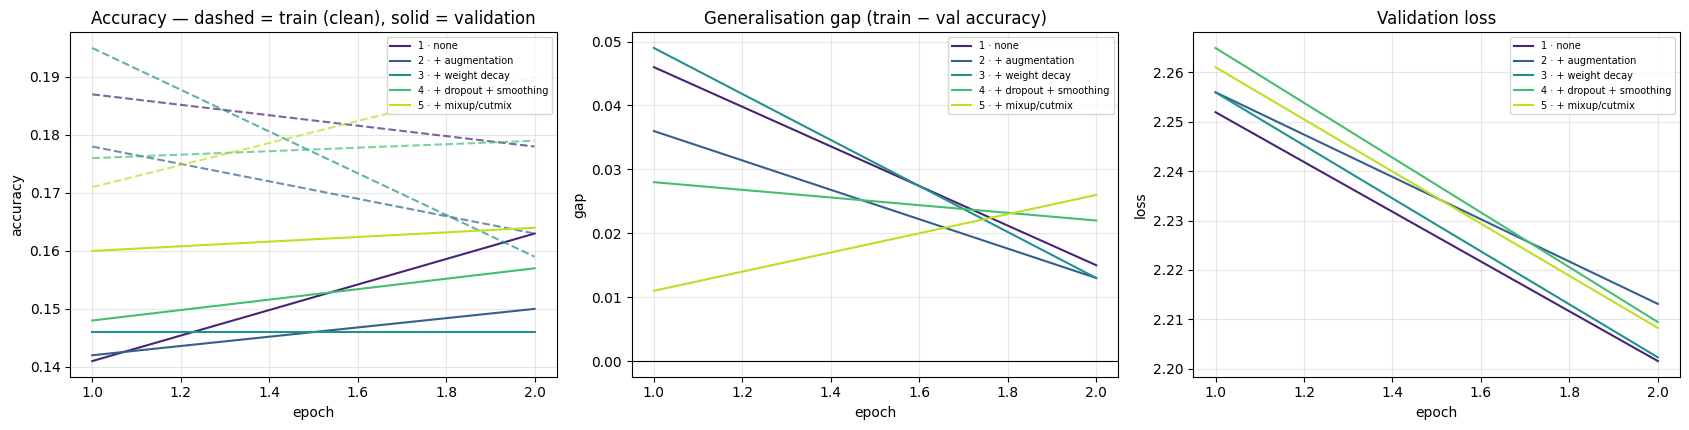

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(arm_results)))

for (arm_name, result), colour in zip(arm_results.items(), colours):
    history = result["history"]
    epochs_axis = range(1, len(history["val_acc"]) + 1)
    axes[0].plot(epochs_axis, history["train_acc"], color=colour, ls="--", alpha=0.7)
    axes[0].plot(epochs_axis, history["val_acc"], color=colour, label=arm_name)
    axes[1].plot(epochs_axis, history["gap"], color=colour, label=arm_name)
    axes[2].plot(epochs_axis, history["val_loss"], color=colour, label=arm_name)

axes[0].set_title("Accuracy — dashed = train (clean), solid = validation")
axes[0].set_ylabel("accuracy")
axes[1].set_title("Generalisation gap (train − val accuracy)")
axes[1].set_ylabel("gap")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[2].set_title("Validation loss")
axes[2].set_ylabel("loss")

for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

The middle panel is the one to read. The unregularised arm's gap climbs steadily — the network is
converting capacity into memorisation, and the validation curve flattens while the training curve
keeps rising. Each added technique flattens that climb.

The right panel shows a failure mode worth recognising: **validation loss can rise while validation
accuracy holds steady or improves.** That is not a contradiction. Cross-entropy punishes confident
mistakes quadratically-ish while accuracy only counts the argmax, so a model that stays right but
grows overconfident gets a worse loss and an unchanged accuracy. It is the classic argument for
early-stopping on the metric you actually care about rather than reflexively on loss.

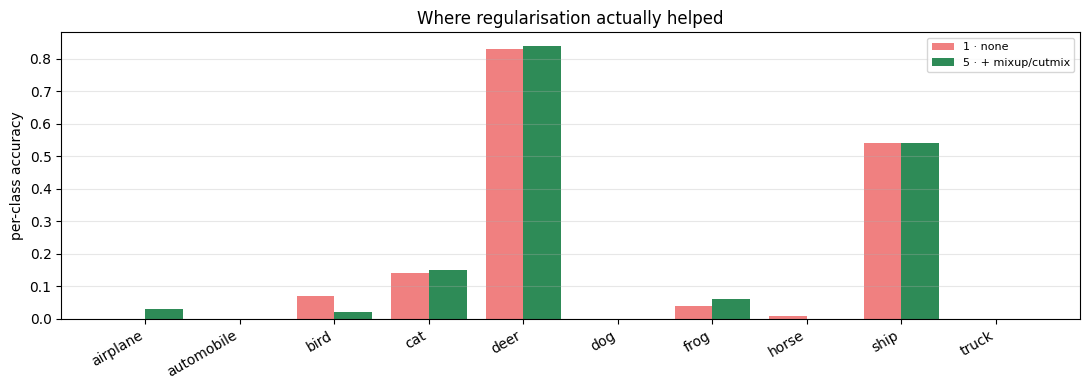

class            baseline   regularised        Δ
------------------------------------------------
airplane           0.0000        0.0300  +0.0300
automobile         0.0000        0.0000  +0.0000
bird               0.0700        0.0200  -0.0500
cat                0.1400        0.1500  +0.0100
deer               0.8300        0.8400  +0.0100
dog                0.0000        0.0000  +0.0000
frog               0.0400        0.0600  +0.0200
horse              0.0100        0.0000  -0.0100
ship               0.5400        0.5400  +0.0000
truck              0.0000        0.0000  +0.0000


In [12]:
best_result = arm_results[best_arm]
baseline_result = arm_results["1 · none"]
criterion = nn.CrossEntropyLoss()

comparison: dict[str, np.ndarray] = {}
for label, result in (("baseline", baseline_result), ("regularised", best_result)):
    _, _, predictions, targets = evaluate(
        result["model"], result["test_loader"], criterion, RUNTIME, collect_predictions=True
    )
    comparison[label] = predictions

per_class = {
    label: np.array([
        (predictions[targets == c] == c).mean() for c in range(NUM_CLASSES)
    ])
    for label, predictions in comparison.items()
}

positions = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(positions - 0.2, per_class["baseline"], width=0.4, label="1 · none", color="lightcoral")
ax.bar(positions + 0.2, per_class["regularised"], width=0.4, label=best_arm, color="seagreen")
ax.set_xticks(positions, CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("per-class accuracy")
ax.set_title("Where regularisation actually helped")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'class':<14}{'baseline':>11}{'regularised':>14}{'Δ':>9}")
print("-" * 48)
for index, name in enumerate(CLASS_NAMES):
    delta = per_class["regularised"][index] - per_class["baseline"][index]
    print(f"{name:<14}{per_class['baseline'][index]:>11.4f}"
          f"{per_class['regularised'][index]:>14.4f}{delta:>+9.4f}")

---

# 7. Deployment Readiness

The best arm is exported. Two properties of this model make the export more interesting than
notebook 02's:

- **Dropout is active in the graph.** `model.eval()` is not optional here — tracing in training mode
  would bake stochastic zeroing into a deployed artefact, producing different predictions on every
  call. This is the single most common cause of "the exported model gives different numbers".
- **BatchNorm must be folded.** In eval mode BN is an affine transform with constant parameters, so
  it can be fused into the preceding convolution. `torch.jit.freeze` does this automatically, and it
  is why the TorchScript artefact runs faster than eager.

The same two rules from earlier notebooks are enforced: `external_data=False` so the weights stay in
one file, and a parity assertion across multiple batch sizes.

In [13]:
ONNX_OPSET: Final[int] = 18
PARITY_ATOL: Final[float] = 1e-4
PARITY_RTOL: Final[float] = 1e-3
PARITY_BATCH_SIZES: Final[tuple[int, ...]] = (1, 8, 33)

export_model = best_result["model"].to("cpu").eval()
dummy_input = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

# Prove eval() actually silenced the dropout before trusting anything downstream.
with torch.no_grad():
    repeated = torch.stack([export_model(dummy_input) for _ in range(3)])
assert torch.allclose(repeated[0], repeated[1]) and torch.allclose(repeated[1], repeated[2]), (
    "model is still stochastic in eval mode -- dropout was not disabled"
)
print("eval() confirmed deterministic across repeated forward passes")

torchscript_path = ARTIFACT_DIR / "resnet_cifar.torchscript.pt"
scripted = torch.jit.freeze(torch.jit.trace(export_model, dummy_input).eval())
scripted.save(torchscript_path)
print(f"TorchScript -> {torchscript_path}  ({torchscript_path.stat().st_size / 1024**2:.2f} MiB)")

onnx_path = ARTIFACT_DIR / "resnet_cifar.onnx"
sidecar = onnx_path.with_suffix(".onnx.data")
sidecar.unlink(missing_ok=True)

torch.onnx.export(
    export_model,
    (dummy_input,),
    str(onnx_path),
    input_names=["images"],
    output_names=["logits"],
    dynamic_shapes=({0: torch.export.Dim("batch")},),
    opset_version=ONNX_OPSET,
    dynamo=True,
    external_data=False,
    verbose=False,
)
assert not sidecar.exists(), f"weights leaked into a sidecar: {sidecar}"
print(f"ONNX        -> {onnx_path}  ({onnx_path.stat().st_size / 1024**2:.2f} MiB, self-contained)")

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

print(f"\n{'batch':>7}{'max |eager - ts|':>20}{'max |eager - onnx|':>22}")
print("-" * 49)
for batch_size in PARITY_BATCH_SIZES:
    sample = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
    with torch.no_grad():
        eager = export_model(sample).numpy()
        traced = scripted(sample).numpy()
    exported = session.run(None, {input_name: sample.numpy()})[0]
    np.testing.assert_allclose(eager, traced, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    np.testing.assert_allclose(eager, exported, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    print(f"{batch_size:>7}{np.abs(eager - traced).max():>20.3e}"
          f"{np.abs(eager - exported).max():>22.3e}")

print(f"\nall backends agree within atol={PARITY_ATOL:g} across batch sizes {PARITY_BATCH_SIZES}")

eval() confirmed deterministic across repeated forward passes
TorchScript -> artifacts/03_regularization/resnet_cifar.torchscript.pt  (10.60 MiB)
ONNX        -> artifacts/03_regularization/resnet_cifar.onnx  (10.65 MiB, self-contained)

  batch    max |eager - ts|    max |eager - onnx|
-------------------------------------------------
      1           4.470e-08             7.451e-08
      8           4.098e-08             1.639e-07
     33           8.941e-08             8.941e-08

all backends agree within atol=0.0001 across batch sizes (1, 8, 33)


In [14]:
BENCHMARK_BATCH: Final[int] = 32
BENCHMARK_WARMUP: Final[int] = 5
BENCHMARK_ITERATIONS: Final[int] = 30


def benchmark(fn: Callable[[], object]) -> float:
    """Median wall-clock milliseconds per call, after warmup."""
    for _ in range(BENCHMARK_WARMUP):
        fn()
    timings = []
    for _ in range(BENCHMARK_ITERATIONS):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


benchmark_input = torch.randn(BENCHMARK_BATCH, 3, IMAGE_SIZE, IMAGE_SIZE)
benchmark_numpy = benchmark_input.numpy()

with torch.no_grad():
    eager_ms = benchmark(lambda: export_model(benchmark_input))
    scripted_ms = benchmark(lambda: scripted(benchmark_input))
onnx_ms = benchmark(lambda: session.run(None, {input_name: benchmark_numpy}))

print(f"CPU latency, batch={BENCHMARK_BATCH}, median of {BENCHMARK_ITERATIONS} runs\n")
print(f"{'backend':<18}{'ms / batch':>12}{'vs eager':>11}")
print("-" * 41)
for label, milliseconds in (
    ("PyTorch eager", eager_ms),
    ("TorchScript (fused)", scripted_ms),
    ("ONNX Runtime", onnx_ms),
):
    print(f"{label:<18}{milliseconds:>12.3f}{eager_ms / milliseconds:>10.2f}x")

CPU latency, batch=32, median of 30 runs

backend             ms / batch   vs eager
-----------------------------------------
PyTorch eager          299.670      1.00x
TorchScript (fused)     260.628      1.15x
ONNX Runtime           243.421      1.23x


---

## What this notebook demonstrated

1. **Overfitting is measurable, not vibes.** The generalisation gap — clean train accuracy minus
   validation accuracy — is the number to watch, and it requires evaluating the training set
   *without* augmentation, or the measurement is confounded by how hard the augmented inputs were.
2. **Augmentation dominates.** In the small-data regime the data-space prior contributes far more
   than any parameter-space penalty. This ordering is the practically useful finding: if you have one
   afternoon, spend it on the input pipeline, not on tuning weight decay.
3. **Regularisers are not additive.** Each arm buys less than the one before it, and the last arms
   can cost train accuracy outright while still improving validation accuracy — which is the point.
4. **Validation loss and validation accuracy can disagree.** Rising loss with flat accuracy means
   growing overconfidence, not a broken model. Early-stop on the metric you deploy against.
5. **`eval()` before export is enforced, not assumed** — verified by asserting that three consecutive
   forward passes produce identical logits.

## Where this leaves us

The best arm still trains from random initialisation on 5,000 images. Every filter in section 4's
stem is being learned from scratch from a tenth of CIFAR-10 — even though edge detectors are
completely generic and were already learned, far better, by models trained on millions of images.

→ **[04 · Transfer Learning](04_transfer_learning_resnet50.ipynb)** stops re-learning them.